# Analise de Vendas de Varejo

**Portfolio de Analise de Dados**

Este notebook explora uma base de vendas de varejo (12.000 transacoes) para
responder perguntas de negocio e gerar insights estrategicos.

**Ferramentas:** Python (pandas, matplotlib, seaborn) + SQL (SQLite)

**Etapas:** os dados ja passaram por um processo de ETL
(`scripts/02_etl.py`) que limpou, padronizou e enriqueceu a base bruta.


## 1. Importacao e carga dos dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

df = pd.read_csv("../dados/tratado/vendas_tratado.csv", encoding="utf-8-sig",
                 parse_dates=["data_venda"])
print(f"Linhas: {len(df):,} | Colunas: {df.shape[1]}")
df.head()

Linhas: 12,000 | Colunas: 23


,venda_id,data_venda,ano,mes,ano_mes,trimestre,dia_semana,produto_id,produto,categoria,...,custo_unitario,custo_total,valor_total,lucro,margem_pct,regiao,cidade,canal,forma_pagamento,cliente_id
0,104781,2024-01-17,2024,1,2024-01,T1,Wednesday,1019,Halteres,Esportes,...,107.57,322.71,870.12,547.41,62.9,Sul,Porto Alegre,E-commerce,Pix,637
1,104122,2024-01-17,2024,1,2024-01,T1,Wednesday,1023,Secador de Cabelo,Beleza,...,72.83,364.15,897.75,533.60,59.4,Nordeste,Fortaleza,App,Boleto,709
2,105092,2024-01-17,2024,1,2024-01,T1,Wednesday,1013,Almofada,Casa e Decoracao,...,20.74,20.74,33.06,12.32,37.3,Norte,Belem,E-commerce,Cartao De Debito,589
3,111512,2024-01-17,2024,1,2024-01,T1,Wednesday,1001,Notebook,Eletronicos,...,2220.02,2220.02,3581.10,1361.08,38.0,Sudeste,Nao Informado,Loja Fisica,Pix,750
4,110071,2024-01-17,2024,1,2024-01,T1,Wednesday,1004,Tablet,Eletronicos,...,701.26,701.26,958.97,257.71,26.9,Centro-Oeste,Brasilia,Loja Fisica,Dinheiro,754


## 2. Visao geral (KPIs)

In [2]:
faturamento = df["valor_total"].sum()
lucro = df["lucro"].sum()
ticket_medio = df["valor_total"].mean()
margem = lucro / faturamento * 100

print(f"Faturamento total..: R$ {faturamento:,.2f}")
print(f"Lucro total........: R$ {lucro:,.2f}")
print(f"Ticket medio.......: R$ {ticket_medio:,.2f}")
print(f"Margem media.......: {margem:.1f}%")
print(f"Itens vendidos.....: {df['quantidade'].sum():,}")
print(f"Periodo............: {df['data_venda'].min():%d/%m/%Y} a {df['data_venda'].max():%d/%m/%Y}")

Faturamento total..: R$ 12,349,398.85
Lucro total........: R$ 4,806,804.78
Ticket medio.......: R$ 1,029.12
Margem media.......: 38.9%
Itens vendidos.....: 23,293
Periodo............: 17/01/2024 a 17/07/2026


## 3. Faturamento por categoria

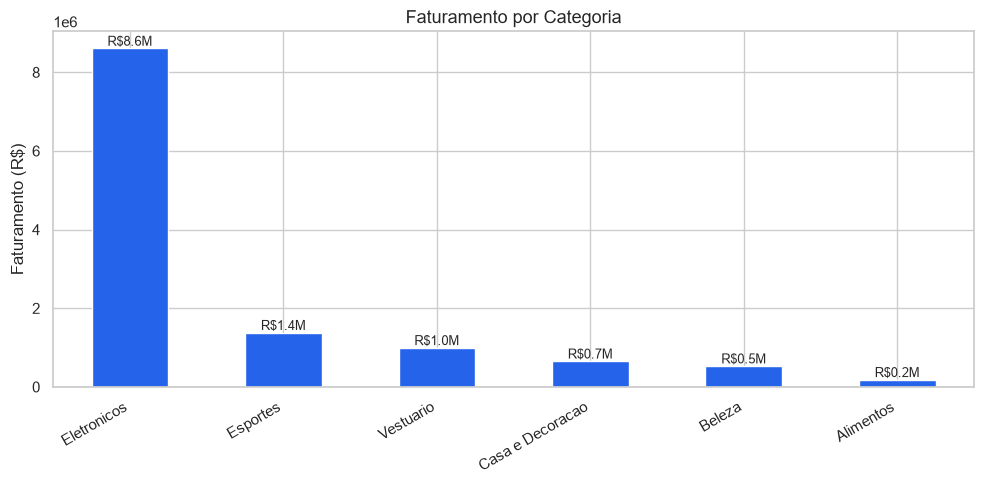

In [3]:
cat = (df.groupby("categoria")["valor_total"].sum()
         .sort_values(ascending=False))

ax = cat.plot(kind="bar", color="#2563eb")
ax.set_title("Faturamento por Categoria")
ax.set_xlabel("")
ax.set_ylabel("Faturamento (R$)")
for i, v in enumerate(cat):
    ax.text(i, v, f"R${v/1e6:.1f}M", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../imagens/01_faturamento_categoria.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** Eletronicos concentra a maior fatia do faturamento, mas
categorias como Alimentos e Vestuario tem margem percentual muito maior.
Vale analisar o equilibrio entre volume (Eletronicos) e rentabilidade.

## 4. Evolucao mensal do faturamento

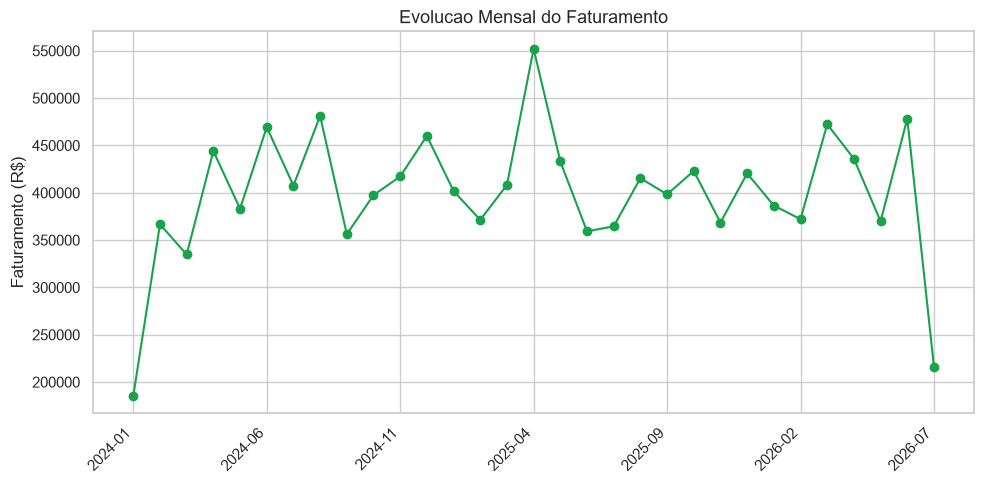

In [4]:
mensal = df.groupby("ano_mes")["valor_total"].sum()

ax = mensal.plot(kind="line", marker="o", color="#16a34a")
ax.set_title("Evolucao Mensal do Faturamento")
ax.set_xlabel("")
ax.set_ylabel("Faturamento (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../imagens/02_evolucao_mensal.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Participacao por regiao

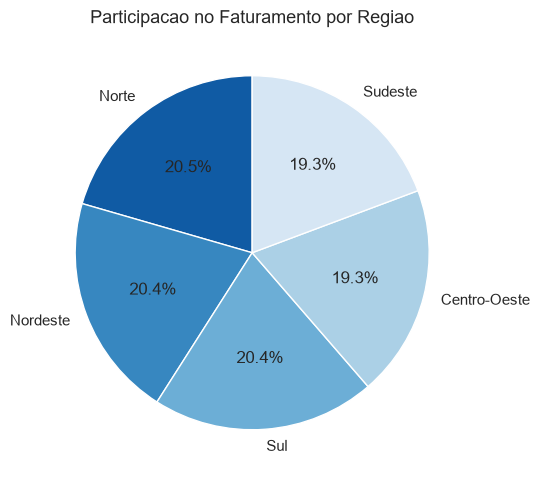

In [5]:
regiao = (df.groupby("regiao")["valor_total"].sum()
            .sort_values(ascending=False))

ax = regiao.plot(kind="pie", autopct="%1.1f%%", startangle=90,
                 colors=sns.color_palette("Blues_r", len(regiao)))
ax.set_title("Participacao no Faturamento por Regiao")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../imagens/03_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Margem de lucro por categoria

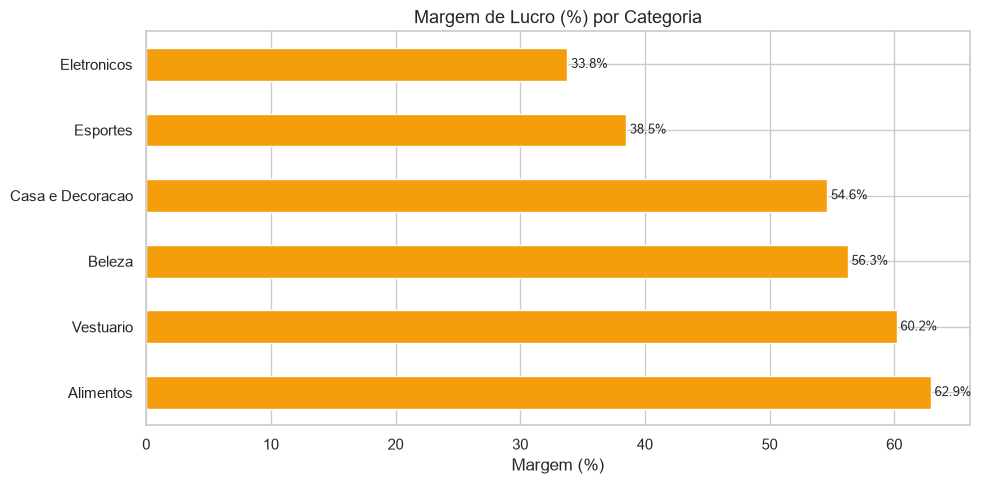

In [6]:
margem_cat = (df.groupby("categoria")
                .apply(lambda g: g["lucro"].sum() / g["valor_total"].sum() * 100)
                .sort_values(ascending=False))

ax = margem_cat.plot(kind="barh", color="#f59e0b")
ax.set_title("Margem de Lucro (%) por Categoria")
ax.set_xlabel("Margem (%)")
ax.set_ylabel("")
for i, v in enumerate(margem_cat):
    ax.text(v, i, f" {v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../imagens/04_margem_categoria.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Desempenho por canal de venda

In [7]:
canal = (df.groupby("canal")
           .agg(faturamento=("valor_total", "sum"),
                ticket_medio=("valor_total", "mean"),
                vendas=("venda_id", "count"))
           .sort_values("faturamento", ascending=False))
canal

,faturamento,ticket_medio,vendas
canal,,,
Loja Fisica,4264506.33,1073.371842,3973
App,4090034.73,1020.722418,4007
E-commerce,3994857.79,993.745719,4020


## 8. Conclusoes e recomendacoes

- **Eletronicos** lidera o faturamento (volume), enquanto **Alimentos e
  Vestuario** entregam as maiores margens -> oportunidade de impulsionar
  categorias rentaveis via cross-sell.
- O **faturamento cresce ao longo do periodo**, com sazonalidade clara em
  alguns meses -> planejar estoque e campanhas para os picos.
- A regiao **Sudeste** concentra a maior parte das vendas -> avaliar
  potencial de expansao nas regioes menos exploradas.
- Canais **digitais (E-commerce/App)** merecem atencao pelo ticket medio.

> Proximos passos: construir o dashboard no Power BI / Looker Studio para
> acompanhamento continuo desses indicadores.
